In [124]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification")

Skipping, found downloaded files in "./tom-and-jerry-image-classification" (use force=True to force download)


In [125]:
import pandas as pd
import numpy as np
import tensorflow as tf
import sklearn
import matplotlib.pyplot as plt

In [126]:
df = pd.read_csv('/content/tom-and-jerry-image-classification/challenges.csv')
df.head()

,folder,image_name
0,jerry,frame360.jpg
1,jerry,frame1794.jpg
2,jerry,frame1795.jpg
3,jerry,frame2231.jpg
4,jerry,frame2234.jpg


In [127]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/tom-and-jerry-image-classification/tom_and_jerry/tom_and_jerry",
    labels="inferred",
    label_mode="int",
    validation_split=0.2,   # 80% train, 20% validation
    subset="training",
    seed=42,
    image_size=(256, 256),
    batch_size=32,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/tom-and-jerry-image-classification/tom_and_jerry/tom_and_jerry",
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(256, 256),
    batch_size=32,
)

Found 5478 files belonging to 4 classes.
Using 4383 files for training.
Found 5478 files belonging to 4 classes.
Using 1095 files for validation.


In [128]:
class_names = train_ds.class_names
print(class_names)

['jerry', 'tom', 'tom_jerry_0', 'tom_jerry_1']


In [129]:
images_by_class = {i: [] for i in range(len(class_names))}

In [130]:
for images, labels in train_ds.take(10):
  for img, label in zip(images, labels):
    label = int(label.numpy())
    if len(images_by_class[label]) < 4:
      images_by_class[label].append(img.numpy())

In [131]:
import random

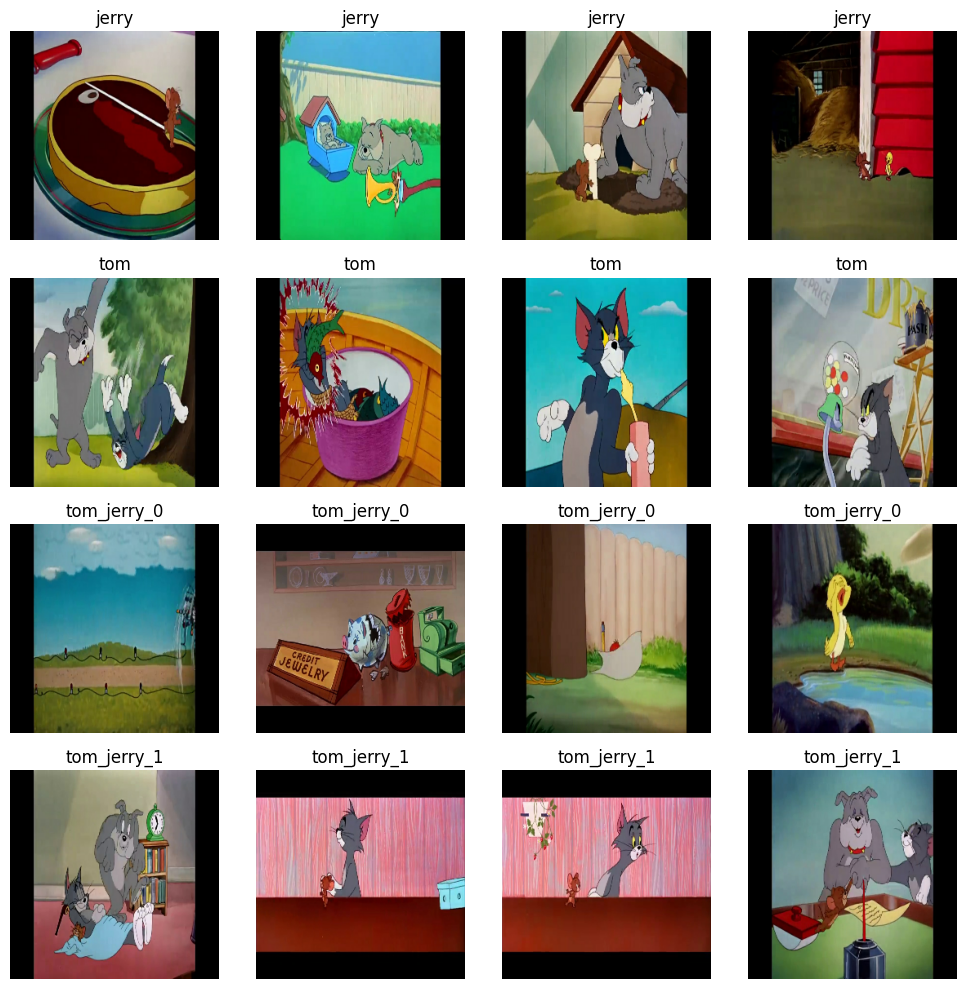

In [132]:
num_per_class = 4
plt.figure(figsize=(10,10))

plot_index = 1

for class_idx, class_name in enumerate(class_names):
    selected_imgs = random.sample(images_by_class[class_idx], num_per_class)

    for img in selected_imgs:
        plt.subplot(len(class_names), num_per_class, plot_index)
        plt.imshow(img.astype("uint8"))
        plt.title(class_name)
        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

In [133]:
# model = tf.keras.Sequential([
#     tf.keras.layers.Rescaling(1./255, input_shape=(256,256,3)),

#     tf.keras.layers.Conv2D(64, 3, activation='linear'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.ReLU(),
#     tf.keras.layers.MaxPooling2D(),

#     tf.keras.layers.Conv2D(128, 3, activation='linear'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.ReLU(),
#     tf.keras.layers.MaxPooling2D(),

#     # tf.keras.layers.Conv2D(512, 3, activation='linear'),
#     # tf.keras.layers.BatchNormalization(),
#     # tf.keras.layers.ReLU(),
#     # tf.keras.layers.MaxPooling2D(),

#     tf.keras.layers.GlobalAveragePooling2D(),
#     tf.keras.layers.Dense(128, activation='relu'),
#     tf.keras.layers.Dropout(0.5),
#     tf.keras.layers.Dense(len(class_names), activation='softmax')
#     ])

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(256, 256, 3)),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(len(class_names), activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [134]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [135]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_7 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 254, 254, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 254, 254, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 254, 254, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 125, 125, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 125, 125, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 125, 125, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,444 (365.02 KB)

 Trainable params: 93,060 (363.52 KB)

 Non-trainable params: 384 (1.50 KB)

In [136]:
# val_batches = tf.data.experimental.cardinality(val_ds)
# test_ds = val_ds.take(val_batches // 2)
# val_ds  = val_ds.skip(val_batches // 2)

In [137]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
# test_ds  = test_ds.prefetch(AUTOTUNE)

In [138]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

In [139]:
history = model.fit(
    train_ds,
    batch_size=32,
    epochs=20,
    validation_data=(val_ds)
)

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 35s 198ms/step - accuracy: 0.3835 - loss: 1.4677 - val_accuracy: 0.2219 - val_loss: 1.4869
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.5327 - loss: 1.2059 - val_accuracy: 0.2228 - val_loss: 1.5703
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.6104 - loss: 0.9991 - val_accuracy: 0.2886 - val_loss: 1.4715
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 22s 162ms/step - accuracy: 0.6512 - loss: 0.9107 - val_accuracy: 0.3653 - val_loss: 1.3819
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.6684 - loss: 0.8577 - val_accuracy: 0.6959 - val_loss: 0.9171
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.7170 - loss: 0.7902 - val_accuracy: 0.6484 - val_loss: 0.9388
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 22s 162ms/step - accuracy: 0.7390 - loss: 0.7402 - val_accuracy: 0.7023 - val_loss: 0.8078
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.7679 - loss: 0

Text(0.5, 1.0, 'Train - Accuracy')

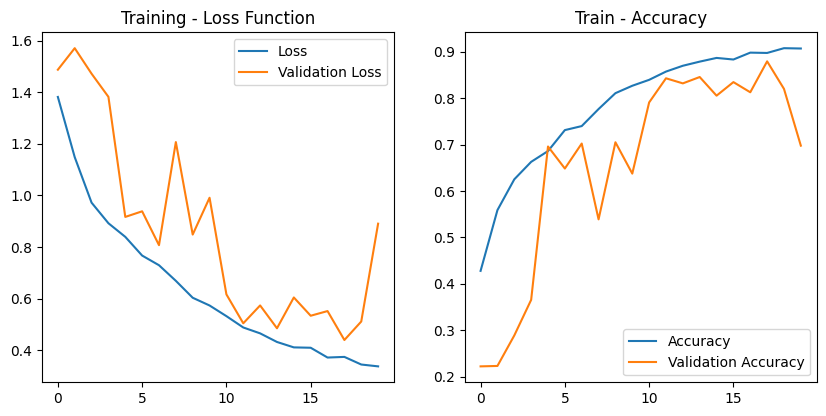

In [140]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training - Loss Function')

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy') # Changed 'acc' to 'accuracy'
plt.plot(history.history['val_accuracy'], label='Validation Accuracy') # Changed 'val_acc' to 'val_accuracy'
plt.legend()
plt.title('Train - Accuracy')

In [141]:
model.save_weights("tom_and_jerry_weights.weights.h5")

In [142]:
model.save("tom_and_jerry_model.h5")